# O(5) Equivariant MLP Demo

This notebook demonstrates soft equivariance and invariance for the 5-dimensional Orthogonal Group $O(5)$. 
Because 5D vectors cannot be visualized geometrically in 3D, we will leverage **Parallel Coordinates** to track internal feature transformations over continuous rotational mappings $R(\theta) = \exp(\theta K)$. We will also construct deep multi-layer O(5) architectures and manage variance scaling perfectly.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import torch
import torch.nn as nn
import numpy as np
import scipy.linalg as sp_linalg
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import gridspec
from IPython.display import Image, display, HTML

## 1. O(5) Vectors and Continuous Exponentiated Rotations
We will generate data uniformly onto a 5D Hypersphere, and define continuous rotational trajectories through O(5) via explicitly projecting a skew-symmetric parameter matrix $K$ natively using $R(\theta) = \exp(\theta \cdot K)$.

In [20]:
def generate_o5_vectors(n_vectors=5, batch_size=1):
    # Sample identically scaled normal random variables mapped onto a valid 5D surface
    x = np.random.randn(batch_size, n_vectors, 5)
    norms = np.linalg.norm(x, axis=-1, keepdims=True)
    x = x / (norms + 1e-8)
    return torch.tensor(x, dtype=torch.float32)

def get_o5_rotation(theta, K=None):
    if K is None:
        # Construct standard structured 5x5 Skew-Symmetric topology
        K = np.zeros((5, 5))
        # Multi-plane rotation (acting across all 5 dimensions)
        K[0, 1] = 1; K[1, 0] = -1
        K[2, 3] = 1; K[3, 2] = -1
        K[4, 0] = 1; K[0, 4] = -1
        K[4, 1] = 1; K[1, 4] = -1
    
    R = sp_linalg.expm(theta * K)
    return torch.tensor(R, dtype=torch.float32), K

torch.manual_seed(42)
np.random.seed(42)

n_vectors = 5
pts = generate_o5_vectors(n_vectors=n_vectors, batch_size=1)[0] # Shape (5, 5)
print("Base O(5) Feature Matrix perfectly generated with shape:", pts.shape)

Base O(5) Feature Matrix perfectly generated with shape: torch.Size([5, 5])


## 2. Invariant and Equivariant O(5) Filter Initialization
We leverage `O5ConstraintsVec` to project our parameter boundaries. This supports both the Singular Value Decomposition (SVD) standard filtering via `InvariantProjector` and the distinct alternative metric via standard Schur decompositions recursively combined via `MultiConstraintInvariantProjector`.

In [21]:
import torch
import torch.nn as nn
from softeq.equi_utils.o5_filter import get_invariant_filter_o5, get_equivariant_filter_o5

# Quick validation to assert logic
if __name__ == "__main__":
    test_layer = get_equivariant_filter_o5(input_size=5, output_size=5, use_invariant_filter=True, soft_threshold=0.1)
    test_x = torch.randn(2, 5, 5) # Batch 2, 5 vectors, dim 5
    print("Successfully initialized filters from o5_filter.py!")

last_basis_idx and total basis: tensor(2) 25
Successfully initialized filters from o5_filter.py!


In [24]:
from softeq.layers.flinear import FLinear

softness_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_inits = 10
n_batches = 100

# Generate eval set
pts_batch_eval = generate_o5_vectors(n_vectors=5, batch_size=n_batches) # Shape (50, 5, 5)
flat_pts_batch_eval = pts_batch_eval.view(n_batches, 25)

models_inv = []
for s in softness_vals:
    inits = []
    inv_filter = get_invariant_filter_o5(input_size=5, soft_threshold=s, hard_mask=True, hard=True)
    # The filter expects 5 input dimensions
    for _ in range(n_inits):
        # We process 5 channels, each 5 dim
        fc = FLinear(in_features=25, out_features=1, bias=False, filter=inv_filter)
        inits.append(fc)
    models_inv.append(inits)

print("Invariant models initialized.")

last_basis_idx and total basis: -1 5
last_basis_idx and total basis: -1 5
last_basis_idx and total basis: 0 5
last_basis_idx and total basis: 1 5
last_basis_idx and total basis: 2 5
last_basis_idx and total basis: 3 5
Invariant models initialized.


Pre-calculating error distributions for boxplots...


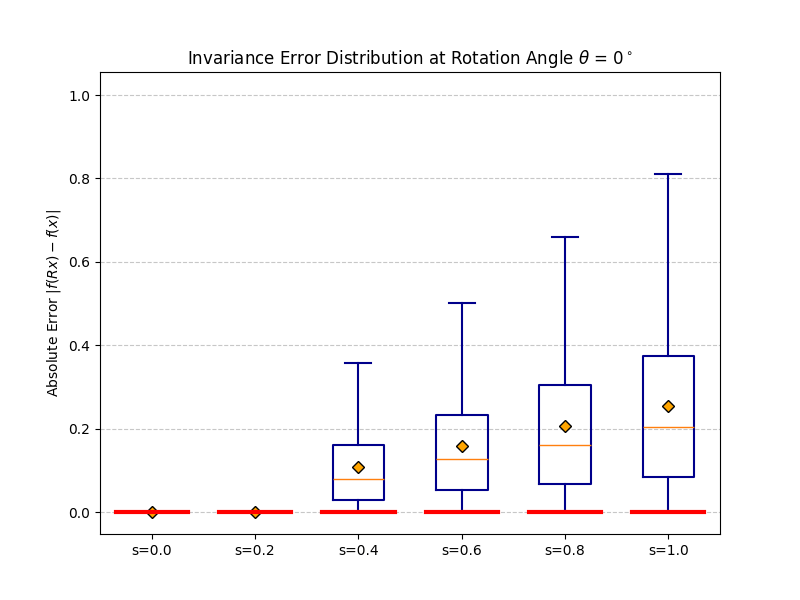

In [25]:
angles = np.linspace(0, 2*np.pi, 40)

# Precompute rotations
_, K = get_o5_rotation(0) # Get standard K
R_matrices = [get_o5_rotation(th, K)[0] for th in angles]

# Precalculate distributions for boxplots
print("Pre-calculating error distributions for boxplots...")
global_errors = [[] for _ in softness_vals]
frame_mean_errors = [[] for _ in softness_vals]

with torch.no_grad():
    base_outs = [
        [m(flat_pts_batch_eval) for m in inits]
        for inits in models_inv
    ]
    for an, R in zip(angles, R_matrices):
        rot_pts_batch = (pts_batch_eval @ R.T).contiguous().view(n_batches, 25)
        for s_idx in range(len(softness_vals)):
            errs = []
            for i_idx in range(n_inits):
                out = models_inv[s_idx][i_idx](rot_pts_batch)
                errs.append((out - base_outs[s_idx][i_idx]).abs().view(-1))
            
            frame_errs_tensor = torch.cat(errs)
            global_errors[s_idx].append(frame_errs_tensor)
            frame_mean_errors[s_idx].append(frame_errs_tensor.mean().item())

global_errors_numpy = [torch.cat(e).numpy() for e in global_errors]
max_err = max([np.percentile(e, 99) for e in global_errors_numpy])
y_max = float(max_err * 1.2) + 1e-3

fig_inv = plt.figure(figsize=(8, 6))
ax_inv = fig_inv.add_subplot(111)
bar_labels = [f"s={s:.1f}" for s in softness_vals]

def update_inv(frame):
    ax_inv.clear()
    
    boxprops = dict(linewidth=1.5, color='darkblue')
    whiskerprops = dict(linewidth=1.5, color='darkblue')
    capprops = dict(linewidth=1.5, color='darkblue')
    meanprops = dict(marker='D', markeredgecolor='black', markerfacecolor='orange')
    
    ax_inv.boxplot(global_errors_numpy, positions=np.arange(len(softness_vals)), 
                showfliers=False, widths=0.5, showmeans=True,
                boxprops=boxprops, whiskerprops=whiskerprops, 
                capprops=capprops, meanprops=meanprops)
                
    # Track the current mean error with a horizontal line
    for s_idx in range(len(softness_vals)):
        current_mean = frame_mean_errors[s_idx][frame]
        ax_inv.plot([s_idx - 0.35, s_idx + 0.35], [current_mean, current_mean], color='red', linewidth=3, zorder=5)

    ax_inv.set_xticks(np.arange(len(softness_vals)))
    ax_inv.set_xticklabels(bar_labels)
    ax_inv.set_ylim([-y_max*0.05, y_max])
    ax_inv.set_ylabel(r"Absolute Error $|f(Rx) - f(x)|$")
    ax_inv.set_title(rf"Invariance Error Distribution at Rotation Angle $\theta$ = {np.degrees(angles[frame]):.0f}$^\circ$")
    ax_inv.grid(True, axis='y', linestyle='--', alpha=0.7)

ani_inv = animation.FuncAnimation(fig_inv, update_inv, frames=len(angles), interval=100)
os.makedirs('figs', exist_ok=True)
ani_inv.save('figs/o5_invariant.gif', writer='pillow')
plt.close(fig_inv)

display(Image(filename='figs/o5_invariant.gif'))

## 4. Equivariant Layer Evaluation

Here we evaluate $V \to V$ equivariant mappings. We measure how well the layer satisfies $L(R \cdot x) = R \cdot L(x)$. Then we visualize these 5D trajectories specifically mapping dimensions as (Dim1, Dim2) in 2D, (Dim3, Dim4) in 2D, and (Dim5) in a 1D graph.

last_basis_idx and total basis: tensor(0) 25
last_basis_idx and total basis: tensor(4) 25
last_basis_idx and total basis: tensor(9) 25
last_basis_idx and total basis: tensor(13) 25
last_basis_idx and total basis: tensor(18) 25
last_basis_idx and total basis: tensor(23) 25
Creating Equivariant Projector for generator  0
Creating Equivariant Projector for generator  1
Creating Equivariant Projector for generator  2
Creating Equivariant Projector for generator  3
Creating Equivariant Projector for generator  4
Creating Equivariant Projector for generator  5
Creating Equivariant Projector for generator  6
Creating Equivariant Projector for generator  7
Creating Equivariant Projector for generator  8
Creating Equivariant Projector for generator  9
Creating Equivariant Projector for generator  10
Creating Equivariant Projector for generator  0
Creating Equivariant Projector for generator  1
Creating Equivariant Projector for generator  2
Creating Equivariant Projector for generator  3
Creati

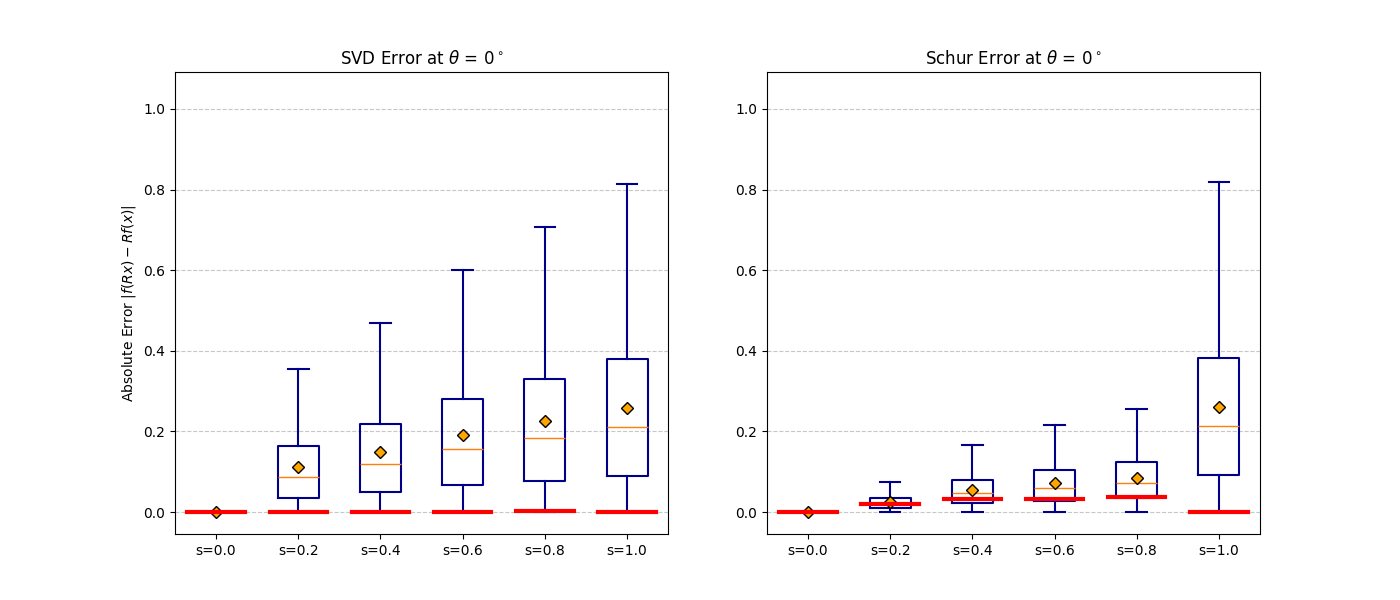

In [26]:
models_eq_svd = []
for s in softness_vals:
    inits = []
    # hidden_dim is not exactly the number of vectors strictly in o5_filter, 
    # but the logic there multiplies by 5. We use input_size=5 explicitly as the number of input vectors.
    eq_filter = get_equivariant_filter_o5(input_size=5, output_size=5, use_invariant_filter=True, soft_threshold=s)
    for _ in range(n_inits):
        # We output 5 channels (5 vectors) of 5 dim, so 25 out features
        fc = FLinear(in_features=25, out_features=25, bias=False, filter=eq_filter)
        inits.append(fc)
    models_eq_svd.append(inits)
    
models_eq_schur = []
for s in softness_vals:
    inits = []
    eq_filter = get_equivariant_filter_o5(input_size=5, output_size=5, use_invariant_filter=False, soft_threshold=s)
    for _ in range(n_inits):
        fc = FLinear(in_features=25, out_features=25, bias=False, filter=eq_filter)
        inits.append(fc)
    models_eq_schur.append(inits)

# Compute Errors distributions for boxplots
print("Pre-calculating equivariant error distributions for boxplots...")
def collect_eq_errors(models_list):
    global_errors = [[] for _ in softness_vals]
    frame_mean_errors = [[] for _ in softness_vals]
    
    with torch.no_grad():
        base_outs = [
            [m(flat_pts_batch_eval).view(n_batches, 5, 5) for m in inits]
            for inits in models_list
        ]
        for an, R in zip(angles, R_matrices):
            rot_pts_batch = (pts_batch_eval @ R.T).contiguous().view(n_batches, 25)
            for s_idx in range(len(softness_vals)):
                errs = []
                for i_idx in range(n_inits):
                    out_of_rot = models_list[s_idx][i_idx](rot_pts_batch).view(n_batches, 5, 5)
                    rot_of_out = base_outs[s_idx][i_idx] @ R.T
                    
                    diff = (out_of_rot - rot_of_out).abs().view(-1)
                    errs.append(diff)
                
                frame_errs_tensor = torch.cat(errs)
                global_errors[s_idx].append(frame_errs_tensor)
                frame_mean_errors[s_idx].append(frame_errs_tensor.mean().item())
    return global_errors, frame_mean_errors

svd_global_errors, svd_frame_means = collect_eq_errors(models_eq_svd)
schur_global_errors, schur_frame_means = collect_eq_errors(models_eq_schur)

svd_global_numpy = [torch.cat(e).numpy() for e in svd_global_errors]
schur_global_numpy = [torch.cat(e).numpy() for e in schur_global_errors]

max_err_svd = max([np.percentile(e, 99) for e in svd_global_numpy])
max_err_schur = max([np.percentile(e, 99) for e in schur_global_numpy])
y_max = float(max(max_err_svd, max_err_schur) * 1.2) + 1e-3

# Animation of Error
fig_eq = plt.figure(figsize=(14, 6))
gs2 = gridspec.GridSpec(1, 2)
ax_eq_svd = fig_eq.add_subplot(gs2[0])
ax_eq_schur = fig_eq.add_subplot(gs2[1])

bar_labels = [f"s={s:.1f}" for s in softness_vals]

def animate_eq(frame):
    ax_eq_svd.clear()
    ax_eq_schur.clear()
    
    boxprops = dict(linewidth=1.5, color='darkblue')
    whiskerprops = dict(linewidth=1.5, color='darkblue')
    capprops = dict(linewidth=1.5, color='darkblue')
    meanprops = dict(marker='D', markeredgecolor='black', markerfacecolor='orange')
    
    # SVD Plot
    ax_eq_svd.boxplot(svd_global_numpy, positions=np.arange(len(softness_vals)), 
                showfliers=False, widths=0.5, showmeans=True,
                boxprops=boxprops, whiskerprops=whiskerprops, 
                capprops=capprops, meanprops=meanprops)
                
    for s_idx in range(len(softness_vals)):
        current_mean = svd_frame_means[s_idx][frame]
        ax_eq_svd.plot([s_idx - 0.35, s_idx + 0.35], [current_mean, current_mean], color='red', linewidth=3, zorder=5)

    ax_eq_svd.set_xticks(np.arange(len(softness_vals)))
    ax_eq_svd.set_xticklabels(bar_labels)
    ax_eq_svd.set_ylim([-y_max*0.05, y_max])
    ax_eq_svd.set_ylabel(r"Absolute Error $|f(Rx) - R f(x)|$")
    ax_eq_svd.set_title(rf"SVD Error at $\theta$ = {np.degrees(angles[frame]):.0f}$^\circ$")
    ax_eq_svd.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Schur Plot
    ax_eq_schur.boxplot(schur_global_numpy, positions=np.arange(len(softness_vals)), 
                showfliers=False, widths=0.5, showmeans=True,
                boxprops=boxprops, whiskerprops=whiskerprops, 
                capprops=capprops, meanprops=meanprops)
                
    for s_idx in range(len(softness_vals)):
        current_mean = schur_frame_means[s_idx][frame]
        ax_eq_schur.plot([s_idx - 0.35, s_idx + 0.35], [current_mean, current_mean], color='red', linewidth=3, zorder=5)

    ax_eq_schur.set_xticks(np.arange(len(softness_vals)))
    ax_eq_schur.set_xticklabels(bar_labels)
    ax_eq_schur.set_ylim([-y_max*0.05, y_max])
    ax_eq_schur.set_title(rf"Schur Error at $\theta$ = {np.degrees(angles[frame]):.0f}$^\circ$")
    ax_eq_schur.grid(True, axis='y', linestyle='--', alpha=0.7)

ani_eq = animation.FuncAnimation(fig_eq, animate_eq, frames=len(angles), interval=100)
os.makedirs('figs', exist_ok=True)
ani_eq.save('figs/o5_equivariant_err.gif', writer='pillow')
plt.close(fig_eq)

display(Image(filename='figs/o5_equivariant_err.gif'))

## Model


In [27]:
import torch.nn as nn
import pandas as pd
from utils.eq_layernorm import EQLayerNorm
from utils.eq_nonlin import EQNonLin
from softeq.layers.flinear import FLinear
from softeq.equi_utils.o5_filter import get_equivariant_filter_o5, get_invariant_filter_o5
from utils.representation_utils import get_representation_size

class DeepO5InvariantModel(nn.Module):
    def __init__(self, in_channels=5, hidden_channels=5, num_layers=3, use_svd=True, in_rep="V", hidden_rep="V*V"):
        """
        Deep O(5) Invariant Model sequence:
        Layer 1: (V) -> (V*V)
        Layer 2..N: (V*V) -> (V*V)
        Final: (V*V) -> Scalar
        """
        super().__init__()
        self.layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.nonlins = nn.ModuleList()
        
        self.in_rep = in_rep
        self.hidden_rep = hidden_rep
        self.in_rep_size = get_representation_size(in_rep, group_name="O(5)")
        self.hidden_rep_size = get_representation_size(hidden_rep, group_name="O(5)")
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        
        # 1. First layer: Maps from V (dim 5) to V*V (dim 25)
        first_filter = get_equivariant_filter_o5(
            input_size=self.in_rep_size, 
            output_size=self.hidden_rep_size, 
            use_invariant_filter=use_svd,
            in_rep=self.in_rep,
            out_rep=self.hidden_rep
        )
        self.layers.append(FLinear(in_features=in_channels * self.in_rep_size, 
                                   out_features=hidden_channels * self.hidden_rep_size, 
                                   bias=False, filter=first_filter))
        self.norms.append(EQLayerNorm([hidden_channels * self.hidden_rep_size], dim=self.hidden_rep_size))
        self.nonlins.append(EQNonLin(dim=self.hidden_rep_size, n_channels=hidden_channels))
        
        # 2. Hidden layers: V*V -> V*V
        for i in range(num_layers - 1):
            layer_filter = get_equivariant_filter_o5(
                input_size=self.hidden_rep_size, 
                output_size=self.hidden_rep_size, 
                use_invariant_filter=use_svd,
                in_rep=self.hidden_rep,
                out_rep=self.hidden_rep
            )
            self.layers.append(FLinear(in_features=hidden_channels * self.hidden_rep_size, 
                                       out_features=hidden_channels * self.hidden_rep_size, 
                                       bias=False, filter=layer_filter))
            self.norms.append(EQLayerNorm([hidden_channels * self.hidden_rep_size], dim=self.hidden_rep_size))
            self.nonlins.append(EQNonLin(dim=self.hidden_rep_size, n_channels=hidden_channels))
            
        # 3. Invariant projection (Maps dynamically V*V to scalar)
        inv_filter = get_invariant_filter_o5(
            input_size=self.hidden_rep_size,
            in_rep=self.hidden_rep
        )
        self.final_inv = FLinear(in_features=hidden_channels * self.hidden_rep_size, out_features=1, bias=True, filter=inv_filter)
        
    def forward(self, x, return_stats=False):
        stats = []
        b_sz = x.shape[0]
        # Map (B, Channels, Dim) -> (B, Channels * Dim)
        out_flat = x.reshape(b_sz, -1)
        
        for i, (layer, norm, nonlin) in enumerate(zip(self.layers, self.norms, self.nonlins)):
            out_flat = layer(out_flat)
            out_ch = out_flat.view(b_sz, self.hidden_channels, self.hidden_rep_size)
            
            if return_stats:
                stats.append({"layer": i+1, "type": "linear", "mean": out_ch.mean().item(), "var": out_ch.var().item()})
                
            out_flat = out_ch.view(b_sz, 1, self.hidden_channels * self.hidden_rep_size)
            out_normed = norm(out_flat)
            out_ch = out_normed.view(b_sz, self.hidden_channels, self.hidden_rep_size)
            if return_stats:
                stats.append({"layer": i+1, "type": "norm", "mean": out_ch.mean().item(), "var": out_ch.var().item()})
                
            out_flat = out_ch.view(b_sz, 1, self.hidden_channels * self.hidden_rep_size)
            out_nl = nonlin(out_flat)
            
            if return_stats:
                out_ch_nl = out_nl.view(b_sz, self.hidden_channels, self.hidden_rep_size)
                stats.append({"layer": i+1, "type": "nonlin", "mean": out_ch_nl.mean().item(), "var": out_ch_nl.var().item()})
            
            out_flat = out_nl.view(b_sz, -1)

        # Final scalar mapping per batch map
        out_final = self.final_inv(out_flat)
        
        if return_stats:
            return out_final, stats
        return out_final

# Exact Sequence Test: V -> V*V -> V*V -> Scalar
deep_model = DeepO5InvariantModel(in_channels=5, hidden_channels=5, num_layers=3, use_svd=True, in_rep="V", hidden_rep="V*V")

# Batch=32, Input=5 vectors of dim=5 (V)
test_x = torch.randn(32, 5, 5) 
pred, stats = deep_model(test_x, return_stats=True)

df_stats = pd.DataFrame(stats)
display(df_stats)


last_basis_idx and total basis: 0 125
last_basis_idx and total basis: tensor(2) 625


last_basis_idx and total basis: tensor(2) 625
last_basis_idx and total basis: tensor(0) 25


,layer,type,mean,var
0,1,linear,0.001070,0.002530
1,1,norm,0.000270,0.040005
2,1,nonlin,0.000197,0.021380
3,2,linear,-0.000213,0.000088
4,2,norm,-0.005128,0.039959
5,2,nonlin,-0.003749,0.021352
6,3,linear,-0.000375,0.000115
7,3,norm,-0.009051,0.039900
8,3,nonlin,-0.006616,0.021320
